In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
df.shape

(908, 13)

In [4]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

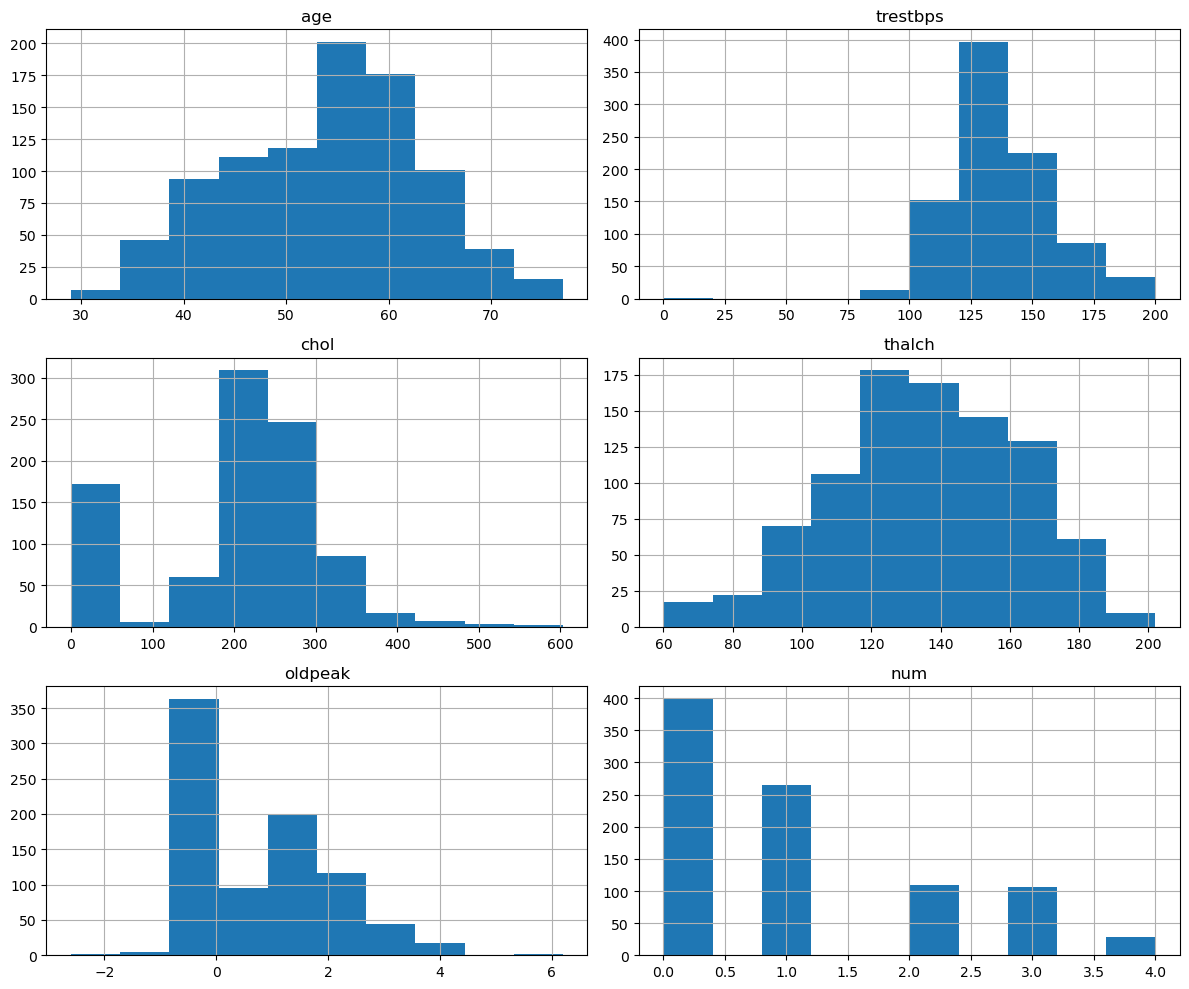

In [8]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

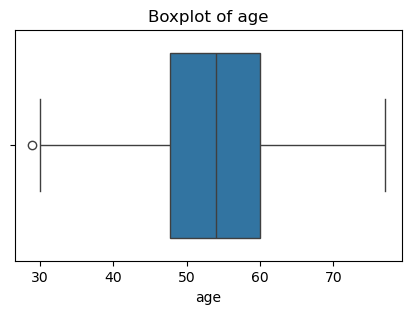

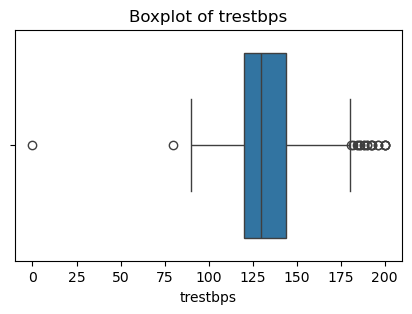

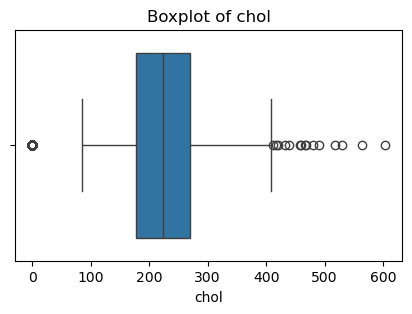

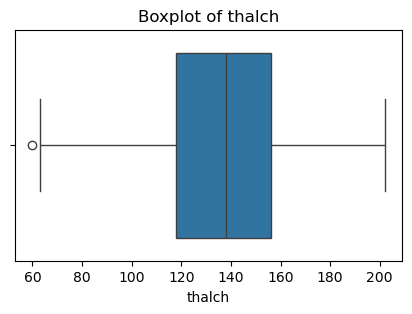

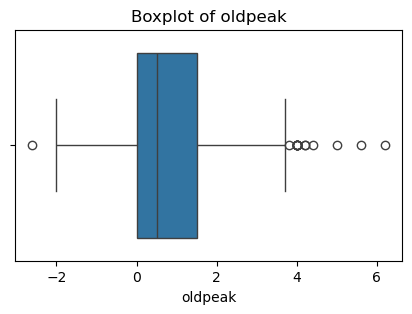

In [9]:
numerical_cols = ['age','trestbps','chol','thalch','oldpeak']

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

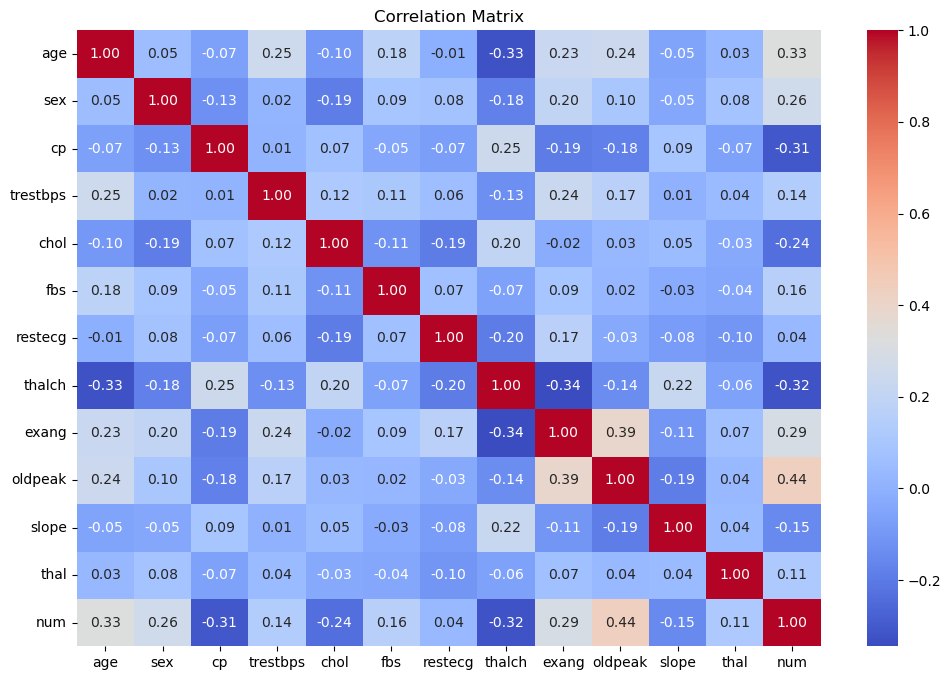

In [11]:
df_corr = df.copy()

# Convert all non-numeric columns to category codes
for col in df_corr.select_dtypes(exclude=['int64','float64']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(12,8))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [12]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' or df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [13]:
for col in df.columns:
    print(col, df[col].dtype)

age int64
sex object
cp object
trestbps int64
chol int64
fbs bool
restecg object
thalch int64
exang object
oldpeak float64
slope object
thal object
num int64


In [14]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].map(type).unique())

sex [<class 'str'>]
cp [<class 'str'>]
restecg [<class 'str'>]
exang [<class 'bool'> <class 'str'>]
slope [<class 'str'>]
thal [<class 'str'>]


In [15]:
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [20]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

Precision: 0.47762311153758524


In [21]:
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)

Recall: 0.5


In [22]:
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)

F1 Score: 0.4877540450213421


In [23]:
y_prob = dt.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr'
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.5704482874167114


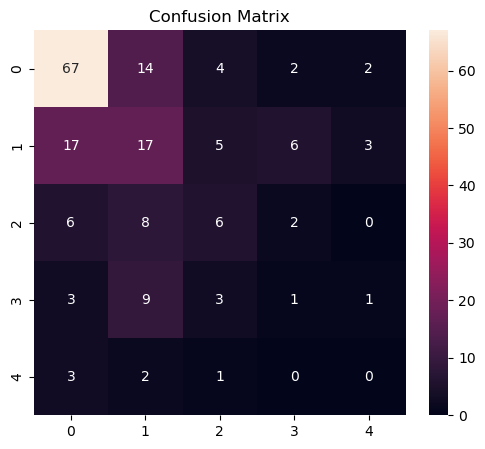

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [25]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,10,None],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [26]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Tuned Accuracy:",
      accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.5659340659340659


In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.538139
4       chol    0.212765
0        age    0.140089
8      exang    0.082762
7     thalch    0.026246
1        sex    0.000000
3   trestbps    0.000000
5        fbs    0.000000
6    restecg    0.000000
9    oldpeak    0.000000
10     slope    0.000000
11      thal    0.000000


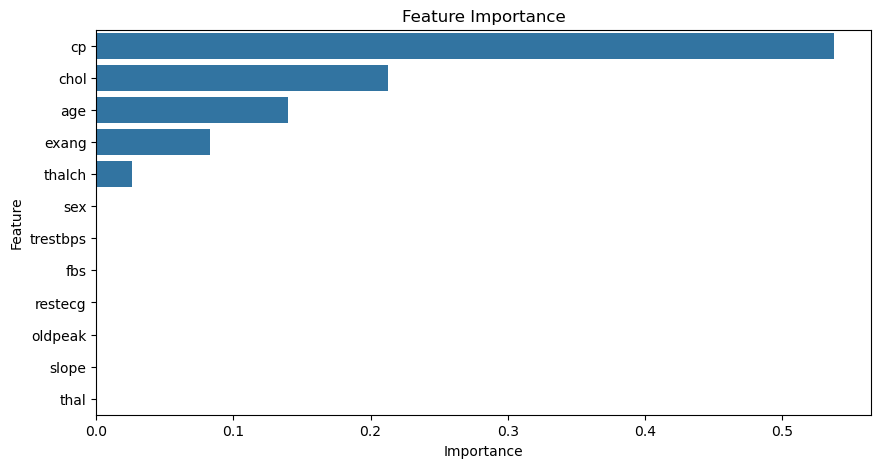

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

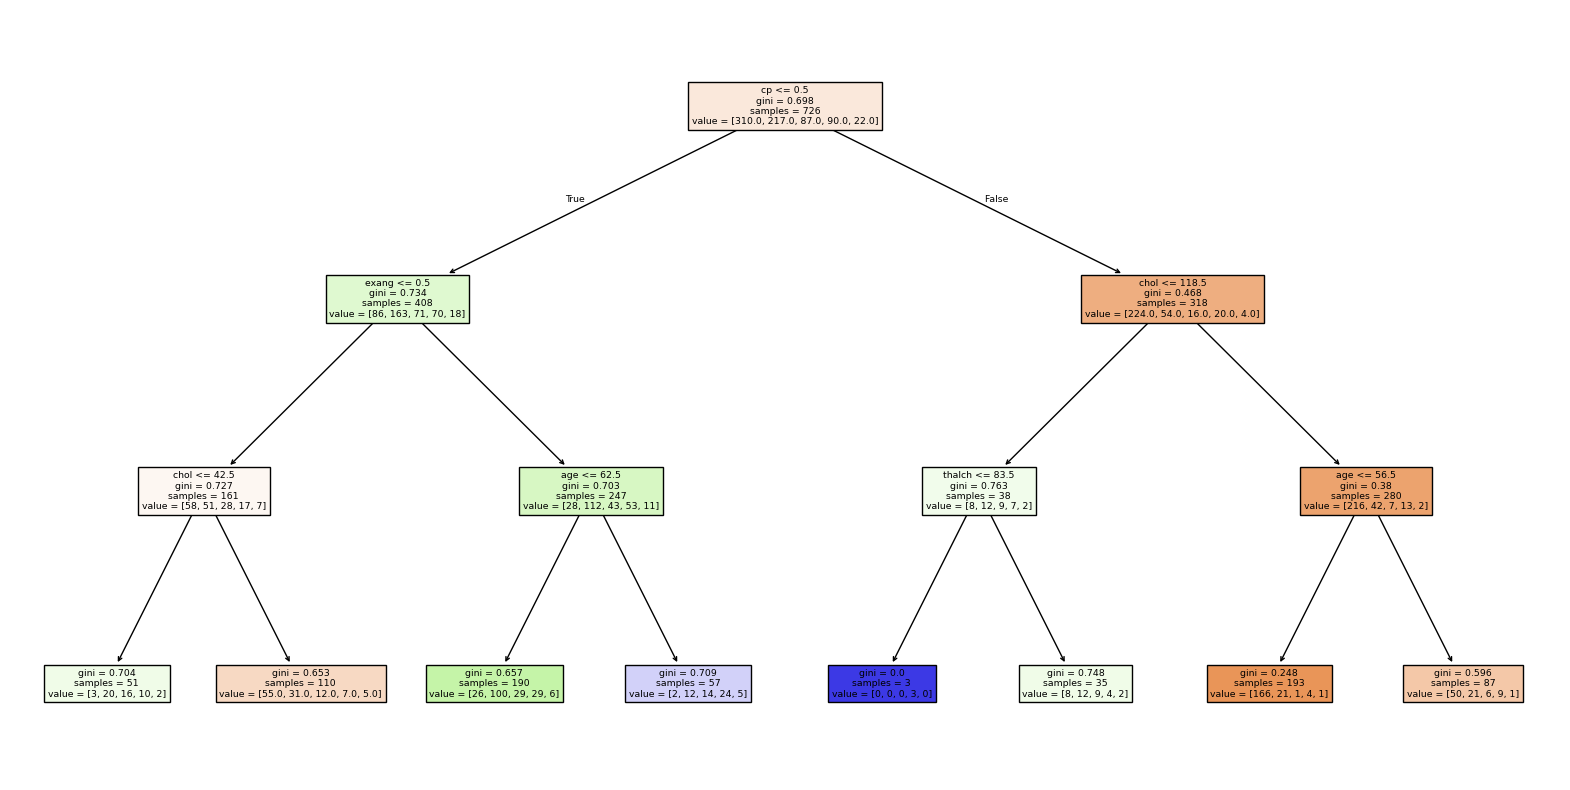

In [29]:
plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [30]:
print("Concluision:The Decision Tree classifier was trained on 80% of the dataset and tested on 20% of the dataset. Hyperparameter tuning improved model performance by selecting the optimal criterion, maximum depth, and minimum samples split. Feature importance analysis revealed the most influential variables contributing to heart disease prediction. The decision tree visualization helped interpret the rules learned by the model.")

Concluision:The Decision Tree classifier was trained on 80% of the dataset and tested on 20% of the dataset. Hyperparameter tuning improved model performance by selecting the optimal criterion, maximum depth, and minimum samples split. Feature importance analysis revealed the most influential variables contributing to heart disease prediction. The decision tree visualization helped interpret the rules learned by the model.


In [31]:
#Interview Question 1
print("""1 Answer:
     max_depth: Controls maximum depth of the tree. Larger depth may lead to overfitting.
     min_samples_split: Minimum samples required to split a node.
     min_samples_leaf: Minimum samples required at a leaf node.
     criterion: Measures quality of split (Gini or Entropy).
     max_features: Number of features considered for splitting.""")

1 Answer:
     max_depth: Controls maximum depth of the tree. Larger depth may lead to overfitting.
     min_samples_split: Minimum samples required to split a node.
     min_samples_leaf: Minimum samples required at a leaf node.
     criterion: Measures quality of split (Gini or Entropy).
     max_features: Number of features considered for splitting.


In [32]:
#Interview Question 2
print("""
Difference Between Label Encoding and One-Hot Encoding

| Label Encoding                          | One-Hot Encoding                |
|-----------------------------------------|---------------------------------|
| Converts categories into numeric values | Creates separate binary columns |
| Uses one column                         | Uses multiple columns           |
| May introduce ordinal relationships     | No ordinal relationship         |
| Suitable for tree-based models          | Suitable for most ML algorithms |
""")


Difference Between Label Encoding and One-Hot Encoding

| Label Encoding                          | One-Hot Encoding                |
|-----------------------------------------|---------------------------------|
| Converts categories into numeric values | Creates separate binary columns |
| Uses one column                         | Uses multiple columns           |
| May introduce ordinal relationships     | No ordinal relationship         |
| Suitable for tree-based models          | Suitable for most ML algorithms |

